In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.colors import BoundaryNorm
from pathlib import Path

import sys
module_path = "../bin"
sys.path.insert(0,module_path)

import um_utils_plotting as umplt
import um_utils as um
from geometry_fix import apply_geometry_collection_fix

apply_geometry_collection_fix()

um.WarningSuppress()

MEANS_DIR = Path("../Data/Models/Monthly_Means")
PROXY_DIR = Path("/Users/ajw1g19/Library/CloudStorage/OneDrive-UniversityofSouthampton/INSPIRE DTP/Projects/Palaeo-Proxies/")

## Fig. S6 - UKESM versus Dawson pre-Industrial land use

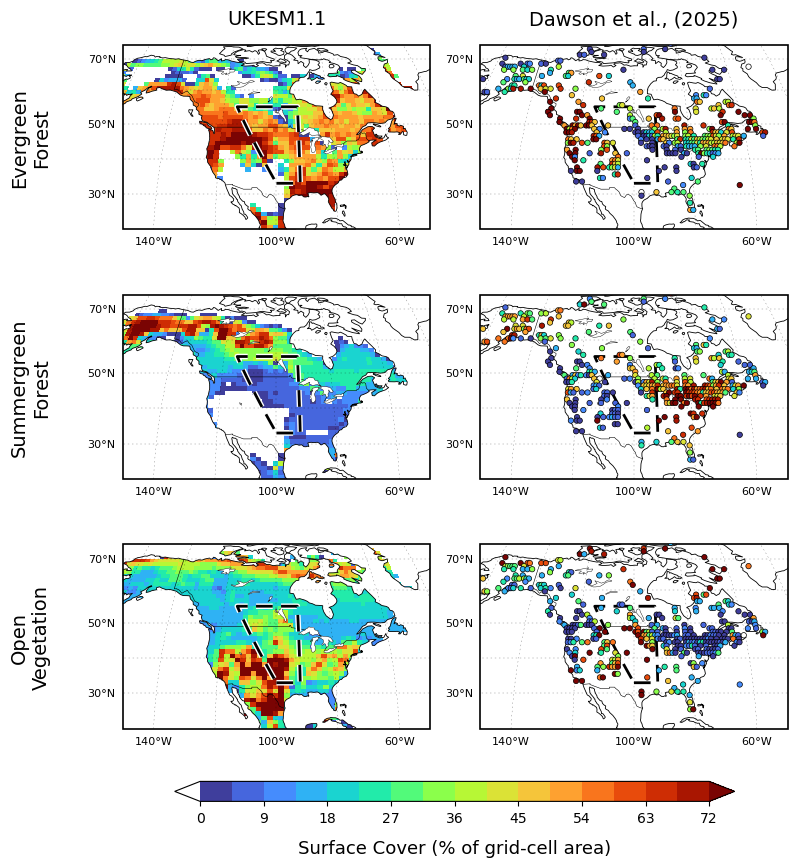

In [ ]:
#------------------------------------------------------------
# Load UKESM and Dawson Data
#------------------------------------------------------------

mh_sfrac = um.importUMData(MEANS_DIR / "MH_monthly_means.nc")["surfacefrac"] * 100
pi_sfrac = um.importUMData(MEANS_DIR / "PI_monthly_means.nc")["surfacefrac"] * 100

# Dawson Vegetation Reconstruction
dawson_vars = ["ET", "ST", "OL"]
df200, df6k = um.importRevealsYrs(PROXY_DIR / "Dawson" / "REVEALS_LCT_gridded.csv", [500, 6000])
dawson_lon, dawson_lat = df200["x"], df200["y"]
for var in dawson_vars:
    df200[var] = df200[var] * 100
    df6k[var] = df6k[var] * 100

GP_region = umplt.umRegion("GP")

#------------------------------------------------------------
# Figure Properties
#------------------------------------------------------------

fig = plt.figure(figsize=(8, 8))
gs = GridSpec(3, 2)

lims, proj = [-150, -50, 20, 75], ccrs.Robinson(central_longitude=-100)
PFTS = {
    "Evergreen\nForest": [1, 2, 4, 12],
    "Summergreen\nForest": [0, 3, 11],
    "Open\nVegetation": [5, 6, 7, 8, 9, 10]
}
labels = ['a', 'b', 'c']

cbar_lab = r"Surface Cover (% of grid-cell area)"
cmap = cm.turbo.copy(); cmap.set_under("white")   
v = 72; levels = np.linspace(1e-1, v, 17)
norm = BoundaryNorm(levels, cmap.N, extend="both")

#------------------------------------------------------------
# Plot Figure
#------------------------------------------------------------

for i, pft in enumerate(PFTS.keys()):
    ax = plt.subplot(gs[i, 0], projection=proj)
    umplt.plotBaseMap(ax, lims, coastlw=0.6, ocean=True, oceancol="white",
                      bordercol="black", borderlw=0.4, lakes=True, lakecol="white", lakelw=0.3,
                      spinelw=1.2)

    umplt.plotGrid(ax, xlabeledlines=[-60, -100, -140], ylabeledlines=[30, 50, 70],
                   xlines=[-40, -80, -120, -160], ylines=[40, 60], labelsize=8, lw=0.2)
    
    pft_sfrac = pi_sfrac[:, PFTS[pft]].sum(dim="surface_tiles", min_count=1).mean(dim="time")

    cf1 = ax.pcolormesh(pft_sfrac.longitude, pft_sfrac.latitude, pft_sfrac, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), zorder=0)

    line_kws = {"color": "black", "linestyle": (0, (6, 3)), "linewidth": 2, "zorder": 6,
                "path_effects": [pe.withStroke(linewidth=4, foreground="white")]}
    GP_region.plot(ax=ax, line_kws=line_kws, add_coastlines=False, add_label=False)

    ax.text(-0.3, 0.5, pft, transform=ax.transAxes, rotation=90,
            ha="center", va="center", fontsize=14)

    if i == 0:
        ax.set_title("UKESM1.1", fontsize=14, pad=15)

    ax = plt.subplot(gs[i, 1], projection=proj)
    umplt.plotBaseMap(ax, lims, coastlw=0.6, ocean=True, oceancol="white", 
                      bordercol="black", borderlw=0.4, lakes=True, lakecol="white", lakelw=0.3, 
                      spinelw=1.2)

    umplt.plotGrid(ax, xlabeledlines=[-60, -100, -140], ylabeledlines=[30, 50, 70],
                   xlines=[-40, -80, -120, -160], ylines=[40, 60], labelsize=8, lw=0.2)

    line_kws = {"color": "black", "linestyle":(0, (6, 3)), "linewidth": 2, "zorder": 6,
                "path_effects": [pe.withStroke(linewidth=4, foreground="white")]}
    GP_region.plot(ax=ax, line_kws=line_kws, add_coastlines=False, add_label=False)

    DAWSON = df200[dawson_vars[i]].values

    p1 = ax.scatter(dawson_lon, dawson_lat, c=DAWSON, s=15, marker="o", cmap=cmap, norm=norm, edgecolors="black", linewidths=0.5, transform=ccrs.PlateCarree(), zorder=9)

    if i == 0:
        ax.set_title("Dawson et al., (2025)", fontsize=14, pad=15)
    
cbaxes = fig.add_axes((0.215,-0.03,0.7,0.025))
cb = fig.colorbar(p1, cax=cbaxes, orientation="horizontal", extend="both")
cb.set_ticks(levels[::2])
cb.set_ticklabels([f"{t:g}" for t in np.linspace(0, v, 17)[::2]])
cb.set_label(cbar_lab, fontsize=13, labelpad=10)
cb.ax.minorticks_off() 

plt.tight_layout()
plt.show()

## Fig. S7 - PFT surface cover in PI and MH

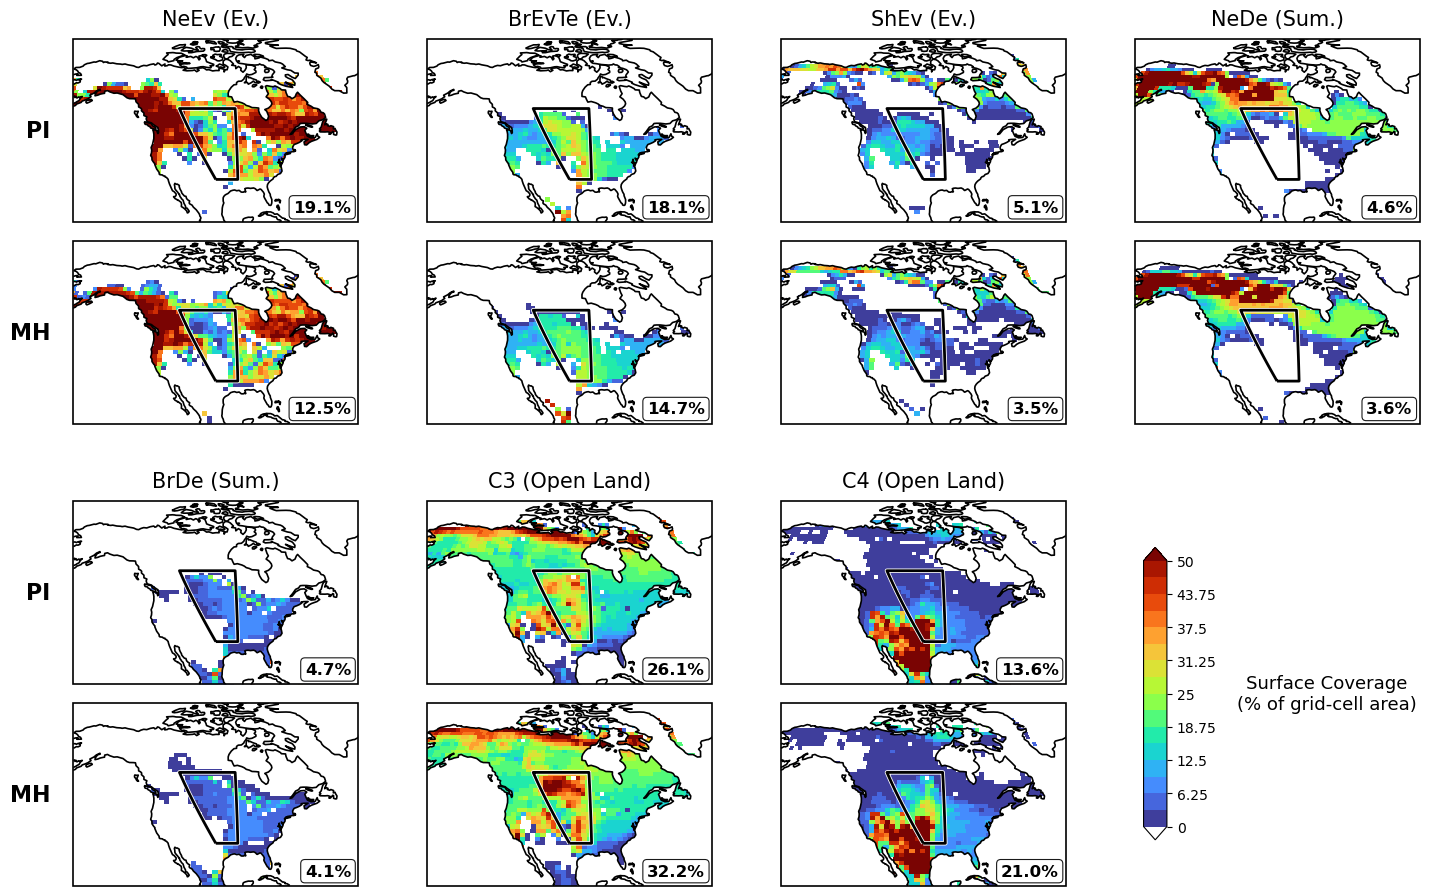

In [ ]:
#------------------------------------------------------------
# Load Sfrac Means
#------------------------------------------------------------

MH_SFRAC = xr.load_dataset(MEANS_DIR / "MH_monthly_means.nc")["surfacefrac"].isel(surface_tiles=slice(None, 13)) * 100
PI_SFRAC = xr.load_dataset(MEANS_DIR / "PI_monthly_means.nc")["surfacefrac"].isel(surface_tiles=slice(None, 13)) * 100

gp_mask = umplt.umRegionMask("GP", MH_SFRAC.longitude, MH_SFRAC.latitude)
gp_reg  = umplt.umRegion("GP")
AREA = np.cos(np.deg2rad(MH_SFRAC.latitude))

#------------------------------------------------------------
# Figure Properties
#------------------------------------------------------------

fig = plt.figure(figsize=(18, 11))
gs  = GridSpec(5, 4, figure=fig, height_ratios=[1, 1, 0.22, 1, 1], hspace=0.12, wspace=0.06)

PLOT_PFTS = {
    "NeEv":   ("NeEv",   "Ev."),
    "BrEvTe": ("BrEvTe", "Ev."),
    "ShEv":   ("ShEv",   "Ev."),
    "NeDe":   ("NeDe",   "Sum."),
    "BrDe":   ("BrDe",   "Sum."),
    "C3Gr":   ("C3",     "Open Land"),
    "C4Gr":   ("C4",     "Open Land"),
}

cmap = cm.turbo.copy(); cmap.set_under("white")      # .copy() so the global turbo isn't mutated
v = 50; levels = np.linspace(1e-1, v, 17)
norm = BoundaryNorm(levels, cmap.N, extend="both")

lims, proj = [-150, -50, 20, 80], ccrs.Robinson(central_longitude=-100)

#------------------------------------------------------------
# Plot Figure
#------------------------------------------------------------

for i, (pft, (label, group)) in enumerate(PLOT_PFTS.items()):

    col, row0 = (i, 0) if i < 4 else (i - 4, 3)      # block A rows 0/1, block B rows 2/3

    for j, (SFRAC, period) in enumerate(zip([PI_SFRAC, MH_SFRAC], ["PI", "MH"])):

        sfrac_plot = SFRAC.sel(surface_tiles=pft).mean(dim="time")
        gp_val     = float(sfrac_plot.where(gp_mask).weighted(AREA).mean(dim=["latitude", "longitude"]))

        ax = fig.add_subplot(gs[row0 + j, col], projection=proj)
        umplt.plotBaseMap(ax, lims, coastlw=1.2, borders=False, ocean=True,
                          oceancol="white", spinelw=1.2)

        p1 = ax.pcolormesh(sfrac_plot.longitude, sfrac_plot.latitude, sfrac_plot,
                           cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), zorder=0)

        before = set(ax.collections)
        line_kws = {"color": "black", "linestyle": "solid", "linewidth": 2, "zorder": 5}
        gp_reg.plot(ax=ax, line_kws=line_kws, add_coastlines=False, add_label=False)

        for coll in set(ax.collections) - before:
            coll.set_path_effects([pe.Stroke(linewidth=3.2, foreground="white"), pe.Normal()])

        # GP mean surface fraction 
        ax.text(0.975, 0.04, f"{gp_val:.1f}%", transform=ax.transAxes,
                ha="right", va="bottom", fontsize=12, fontweight="bold", zorder=6,
                bbox=dict(facecolor="white", edgecolor="black", linewidth=0.8,
                          boxstyle="round,pad=0.25", alpha=0.9))

        # Label rows as MH or PI
        if col == 0:
            ax.text(-0.08, 0.5, period, transform=ax.transAxes, rotation=0,
                    ha="right", va="center", fontsize=16, fontweight="bold")

        # Title columns with the PFT plus group abbrev.
        if j == 0:
            ax.set_title(f"{label} ({group})", fontsize=15, pad=10)

lax = fig.add_subplot(gs[3:, 3]); lax.axis("off")
cax = lax.inset_axes([0.10, 0.12, 0.07, 0.76])

cb = fig.colorbar(p1, cax=cax, orientation="vertical", extend="both")
cb.set_ticks(levels[::2])
cb.set_ticklabels([f"{t:g}" for t in np.linspace(0, v, 17)[::2]])
cb.ax.minorticks_off()

lax.text(0.65, 0.5, "Surface Coverage\n(% of grid-cell area)", transform=lax.transAxes, ha="center", va="center", rotation=0, fontsize=13)

plt.show()


## Fig. S8 - Soil Moisture and Stress Anomalies

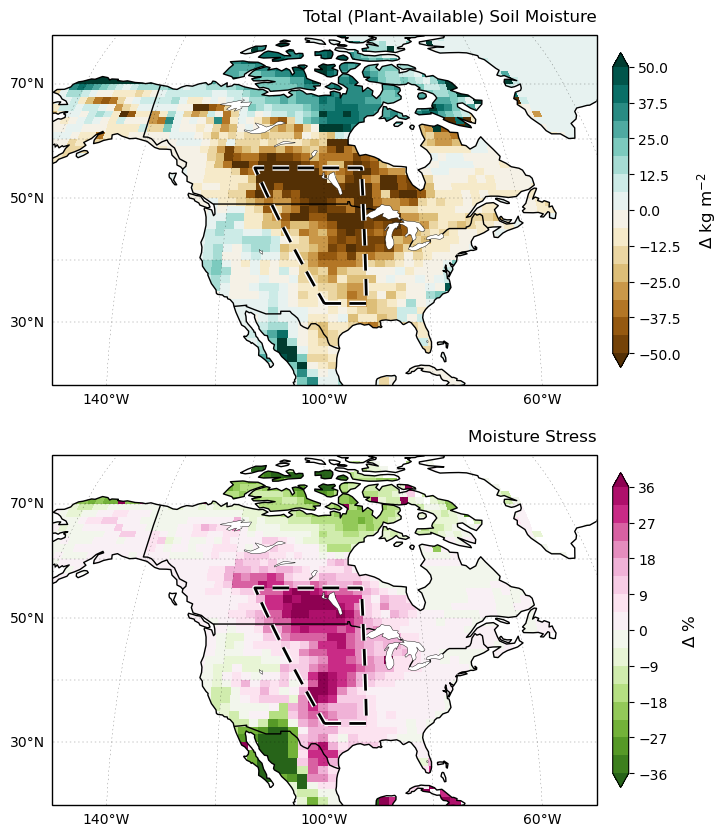

In [ ]:
#------------------------------------------------------------
# Load Data
#------------------------------------------------------------

MH_means = xr.load_dataset(MEANS_DIR / "MH_monthly_means.nc", decode_times=False)
PI_means = xr.load_dataset(MEANS_DIR / "PI_monthly_means.nc", decode_times=False)

sat_vsmc = xr.load_dataset("../Data/Models/sat_vsmc_um13.2.nc")["sat_vsmc"]
DZ = xr.DataArray([0.1, 0.25, 0.65, 2.0], dims="depth", coords={"depth": PI_means.depth.values})

gp_mask = umplt.umRegionMask("GP", MH_means.longitude, MH_means.latitude)
gp_reg = umplt.umRegion("GP")
AREA = np.cos(np.deg2rad(MH_means.latitude))

#------------------------------------------------------------
# Calculate Anomalies
#------------------------------------------------------------

def var_gbm(da, varname):
    """Gridbox mean of a per-PFT field, weighted by tile fraction."""
    var = da[varname]
    sfrac = da["surfacefrac"].isel(surface_tiles=slice(None, 13)).rename({"surface_tiles": "PFTs"})

    return (var * sfrac).sum(dim="PFTs", min_count=1)


def soil_column(da):
    """Total column soil moisture (kg/m2): sum layers, then annual mean."""
    return (da["unfrozen_smc"] * DZ).sum(dim="depth", min_count=1).mean(dim="time") * sat_vsmc * 1000


def beta_gbm(da):
    """Gridbox beta, annual mean."""
    return var_gbm(da, "beta_factor").mean(dim="time")


sm_anom = soil_column(MH_means) - soil_column(PI_means)
beta_anom = (beta_gbm(MH_means) / beta_gbm(PI_means) - 1) * 100

#------------------------------------------------------------
# Figure Properties
#------------------------------------------------------------

fig = plt.figure(figsize=(8, 10))
gs = GridSpec(2, 1)

lims, proj = [-150, -50, 20, 80], ccrs.Robinson(central_longitude=-100)

VARS = {
    "Total (Plant-Available) Soil Moisture": dict(
        data=sm_anom,
        cmap=cm.BrBG, v=50,
        cbar_lab=r"$\Delta$ kg $\mathregular{m^{-2}}$"
    ),
    "Moisture Stress": dict(
        data=-beta_anom, # Negative so that increasing stress is positive
        cmap=cm.PiYG_r, v=36,
        cbar_lab=r"$\Delta$ %"
    )
}

#------------------------------------------------------------
# Plot Figure
#------------------------------------------------------------

axes, mappables, labs = [], [], []
for i, (title, cfg) in enumerate(VARS.items()):
    ax = plt.subplot(gs[i], projection=proj)
    umplt.plotBaseMap(ax, lims, coastlw=1.0, ocean=True, oceancol="white", borders=True, borderlw=1.0, bordercol="black", lakes=True, lakecol="white")
    umplt.plotGrid(ax, xlabeledlines=[-60, -100, -140], ylabeledlines=[30, 50, 70],
                    xlines=[-40, -80, -120, -160], ylines=[20, 40, 60], labelsize=10, lw=0.2)

    plot_var = cfg["data"]
    levels = np.linspace(-cfg["v"], cfg["v"], 17)
    norm = BoundaryNorm(levels, cfg["cmap"].N, extend="both")

    p1 = ax.pcolormesh(plot_var.longitude, plot_var.latitude, plot_var, cmap=cfg["cmap"], norm=norm, transform=ccrs.PlateCarree(), zorder=0)
    ax.set_title(title, loc="right", pad=10)

    line_kws = {"color":"black","linestyle":(0, (6, 3)),"linewidth":2,"zorder":6,
            "path_effects": [pe.withStroke(linewidth=4, foreground="white")]}
    gp_reg.plot(ax=ax,line_kws=line_kws,add_coastlines=False,add_label=False)

    axes.append(ax); mappables.append(p1); labs.append(cfg["cbar_lab"])

fig.canvas.draw()

for ax, mappable, label in zip(axes, mappables, labs):
    pos = ax.get_position()
    cax = fig.add_axes((pos.x1 + 0.02, pos.y0 + pos.height * 0.05, 0.02, pos.height * 0.9))
    cb = fig.colorbar(mappable, cax=cax, orientation="vertical")
    cb.set_label(label, fontsize=12, labelpad=10)
    cb.ax.minorticks_off()

plt.show()
